In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- CARGANDO DATOS ---
df = pd.read_csv('df_0_corrected.csv')

    # Filtrar para tener solo un dato por sujeto
df_u = df.drop_duplicates(subset=['ID_Sujeto']).copy()


--- 2. DISTRIBUCIÓN DE EXPECTATIVA SIN ---

Resumen de Expectativa SIN:
Valor      | Estadísticas (Sujetos | Ensayos)
--------------------------------------------------
-1         | 33 (28.0%) [Ensayos: 198]
0          | 43 (36.4%) [Ensayos: 258]
1          | 42 (35.6%) [Ensayos: 252]


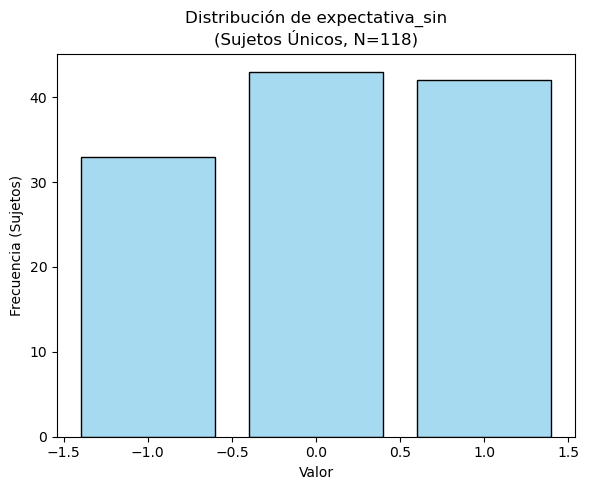

In [3]:
# --- 2. DISTRIBUCIÓN DE VARIABLE CLAVE (SOLO EXPECTATIVA_SIN) ---
print("\n--- 2. DISTRIBUCIÓN DE EXPECTATIVA SIN ---")

# Definimos solo la variable de interés
vars_clave = ['expectativa_sin']

plt.figure(figsize=(6, 5)) # Tamaño ajustado para un solo gráfico

for i, var in enumerate(vars_clave):
    if var in df_u.columns:
        # No hace falta subplot complejo para uno solo, pero mantenemos la lógica simple
        sns.histplot(df_u[var], discrete=True, kde=False, color='skyblue', shrink=0.8)
        plt.title(f'Distribución de {var}\n(Sujetos Únicos, N={len(df_u)})')
        plt.xlabel('Valor')
        plt.ylabel('Frecuencia (Sujetos)')
    else:
        print(f"Warning: {var} not found in columns")

plt.tight_layout()
plt.savefig('distribucion_expectativa_sin.png')

# --- TABLA RESUMEN CON CONTEO DE ENSAYOS ---
n_total_subj = len(df_u)
resumen_datos = {}

for var in vars_clave:
    if var in df_u.columns:
        # 1. Conteo de Sujetos
        conteos_subj = df_u[var].value_counts().sort_index()
        pct_subj = (conteos_subj / n_total_subj * 100).round(1)
        
        # 2. Conteo de Ensayos (Usando el df original completo)
        conteos_trial = df.groupby(var)['ID_Sujeto'].count().sort_index()
        
        # Formatear la salida
        lista_resumen = []
        for idx in conteos_subj.index:
            n_s = conteos_subj.loc[idx]
            p_s = pct_subj.loc[idx]
            n_t = conteos_trial.loc[idx] if idx in conteos_trial.index else 0
            
            # Texto: "N_Sujetos (Porcentaje%) [N_Ensayos Ensayos]"
            lista_resumen.append(f"{n_s} ({p_s}%) [Ensayos: {n_t}]")
            
        resumen_datos[var] = lista_resumen

if resumen_datos:
    print("\nResumen de Expectativa SIN:")
    print(f"{'Valor':<10} | {'Estadísticas (Sujetos | Ensayos)'}")
    print("-" * 50)
    for k, v in resumen_datos.items():
        # Asumiendo índices -1, 0, 1
        indices = [-1, 0, 1] 
        for val, stats in zip(indices, v):
             print(f"{val:<10} | {stats}")

In [6]:
# =============================================================================
# 1. CONFIGURACIÓN DE ANÁLISIS (EDITAR AQUÍ)
# =============================================================================

# Asigna tus DataFrames aquí
TARGET_DF_LONG = df  # dataframe formato largo
TARGET_DF_RESUMEN = df_u # dataframe resumen (un sujeto por fila)

# Define la variable de expectativa y el valor específico a analizar
COLUMNA_EXPECTATIVA = 'expectativa_sin'  # La columna a filtrar
VALOR_EXPECTATIVA = 1                        # El valor específico (ej: 1, -1,0)
NDC_median = 4.66

In [8]:
def classify_ndc(score):
    if pd.isna(score): return 'Unknown'
    return 'High NDC' if score > NDC_median else 'Low NDC'

In [9]:
# =============================================================================
# 2. PREPROCESAMIENTO Y CLASIFICACIÓN GLOBAL (NDC)
# =============================================================================

print("--- Iniciando Preprocesamiento ---")

# A. Limpieza básica en copias para no afectar los originales
# Aseguramos que no haya copias al filtrar por si acaso
df_l = TARGET_DF_LONG.drop_duplicates(subset=['ID_Sujeto', 'Orden_1', 'Orden_2'], keep='first').copy()
df_r = TARGET_DF_RESUMEN.copy()

# B. Extracción de Tratamiento
df_l['Tratamiento'] = df_l['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# C. Clasificación NDC (High vs Low)
if 'NDC_Score' in df_r.columns:
    # Asegurar que sea numérico
    df_r['NDC_Score'] = pd.to_numeric(df_r['NDC_Score'], errors='coerce')
    df_r['NDC_Group'] = df_r['NDC_Score'].apply(classify_ndc)
    # Mapear el grupo al dataframe largo usando ID_Sujeto
    ndc_map = df_r.set_index('ID_Sujeto')['NDC_Group'].to_dict()
    df_l['NDC_Group'] = df_l['ID_Sujeto'].map(ndc_map).fillna('Unknown')

# =============================================================================
# 3. FILTRADO POR EXPECTATIVA ESPECÍFICA
# =============================================================================

print(f"\n{'='*80}")
print(f" ANÁLISIS ESPECÍFICO PARA: {COLUMNA_EXPECTATIVA} = {VALOR_EXPECTATIVA}")
print(f"{'='*80}")

# Filtrar df_long para el valor específico
df_long_filtro = df_l[df_l[COLUMNA_EXPECTATIVA] == VALOR_EXPECTATIVA].copy()

if df_long_filtro.empty:
    raise ValueError(f"No hay datos para {COLUMNA_EXPECTATIVA} = {VALOR_EXPECTATIVA}. Verifica el valor.")

# Filtrar df_resumen para los mismos sujetos
ids_grupo = df_long_filtro['ID_Sujeto'].unique()
df_resumen_filtro = df_r[df_r['ID_Sujeto'].isin(ids_grupo)].copy()

print(f"Sujetos encontrados: {len(ids_grupo)}")

--- Iniciando Preprocesamiento ---

 ANÁLISIS ESPECÍFICO PARA: expectativa_sin = 1
Sujetos encontrados: 42


In [10]:
# =============================================================================
# PREPARACIÓN DE PANELES (INTRA Y ENTRE)
# =============================================================================

# A. Panel 1: Promedio General (Intra-Sujetos) - Desde df_resumen
df_panel1 = df_resumen_filtro.melt(
    id_vars=['ID_Sujeto', 'NDC_Group'], 
    value_vars=['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST'],
    var_name='Tratamiento', 
    value_name='Mantiene'
)
df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')

# B. Panel 2: Promedio Primer Tratamiento (Entre-Sujetos) - Desde df_long
# Solo tomamos Orden_1 == 1
df_panel2 = df_long_filtro[df_long_filtro['Orden_1'] == 1].groupby(
    ['ID_Sujeto', 'Tratamiento', 'NDC_Group']
)['Mantiene'].mean().reset_index()


C:\Users\felip\AppData\Local\Temp\ipykernel_14020\2117298800.py:6: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  df_panel1 = df_resumen_filtro.melt(


Gráfico guardado como: analisis_expectativa_sin_1_ndc_color.png


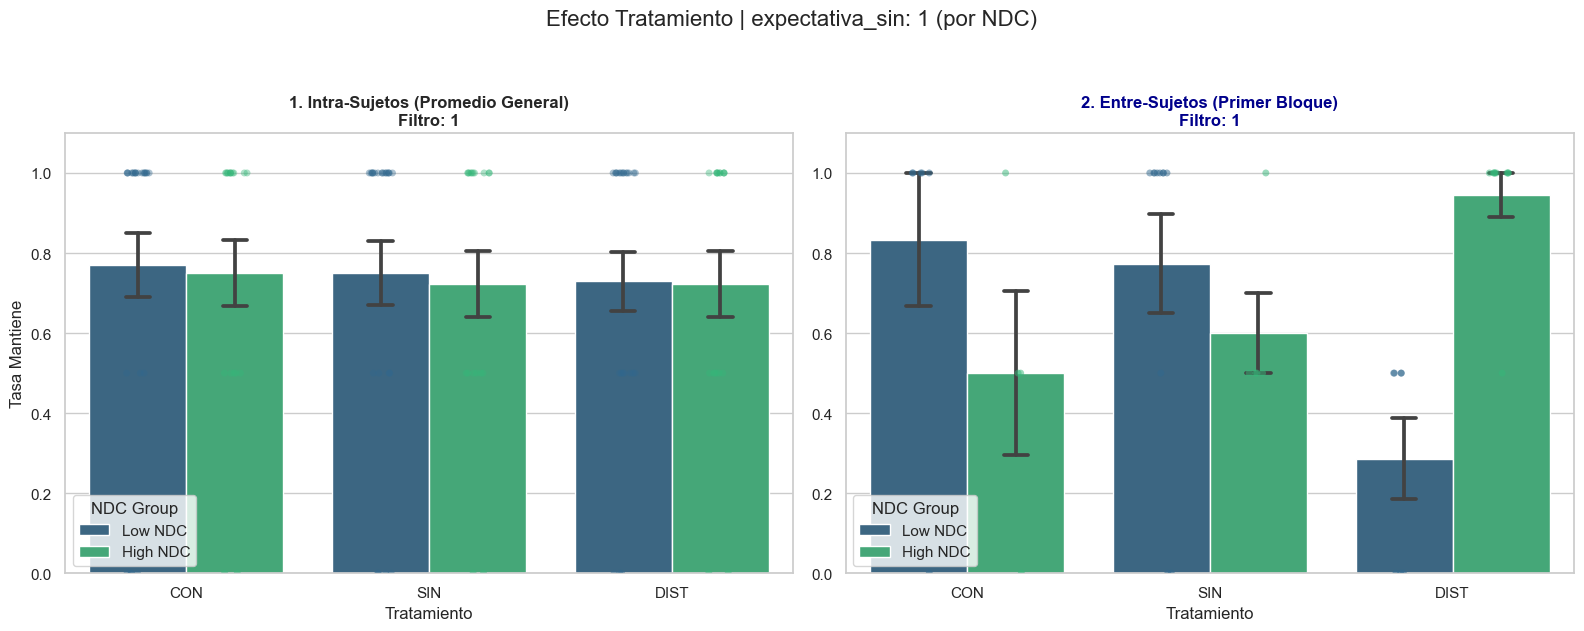


--- RESULTADOS ESTADÍSTICOS (expectativa_sin = 1) ---

1. Intra-sujetos (Todos los bloques):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC      18  0.750  0.083
            Low NDC       24  0.771  0.080
SIN         High NDC      18  0.722  0.083
            Low NDC       24  0.750  0.080
DIST        High NDC      18  0.722  0.083
            Low NDC       24  0.729  0.074

2. Entre-sujetos (Solo primer bloque):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       4  0.500  0.204
            Low NDC        6  0.833  0.167
SIN         High NDC       5  0.600  0.100
            Low NDC       11  0.773  0.124
DIST        High NDC       9  0.944  0.056
            Low NDC        7  0.286  0.101


In [11]:
# =============================================================================
# 5. VISUALIZACIÓN tr4t4miento NDC
# =============================================================================

orden = ['CON', 'SIN', 'DIST']
hue_order = ['Low NDC', 'High NDC']
mi_paleta = 'viridis' 

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico 1: Intra-Sujetos ---
sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', hue='NDC_Group', 
            order=orden, hue_order=hue_order, palette=mi_paleta, 
            errorbar='se', capsize=.1, ax=axes[0])

sns.stripplot(data=df_panel1, x='Tratamiento', y='Mantiene', hue='NDC_Group', 
              order=orden, hue_order=hue_order, palette=mi_paleta, alpha=0.4, 
              jitter=True, dodge=True, ax=axes[0], legend=False) # legend=False evita duplicar

# Leyenda limpia (tomamos los primeros 2 handles que son las barras)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], labels[:2], title='NDC Group')

axes[0].set_title(f'1. Intra-Sujetos (Promedio General)\nFiltro: {VALOR_EXPECTATIVA}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tasa Mantiene')
axes[0].set_ylim(0, 1.1)

# --- Gráfico 2: Entre-Sujetos ---
sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', hue='NDC_Group', 
            order=orden, hue_order=hue_order, palette=mi_paleta, 
            errorbar='se', capsize=.1, ax=axes[1])

sns.stripplot(data=df_panel2, x='Tratamiento', y='Mantiene', hue='NDC_Group', 
              order=orden, hue_order=hue_order, palette=mi_paleta, alpha=0.5, 
              jitter=True, dodge=True, ax=axes[1], legend=False)

# Leyenda limpia
handles2, labels2 = axes[1].get_legend_handles_labels()
axes[1].legend(handles2[:2], labels2[:2], title='NDC Group')

axes[1].set_title(f'2. Entre-Sujetos (Primer Bloque)\nFiltro: {VALOR_EXPECTATIVA}', fontsize=12, fontweight='bold', color='darkblue')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1.1)

# Título General
plt.suptitle(f'Efecto Tratamiento | {COLUMNA_EXPECTATIVA}: {VALOR_EXPECTATIVA} (por NDC)', fontsize=16, y=1.05)
plt.tight_layout()

# Guardar
filename = f'analisis_{COLUMNA_EXPECTATIVA}_{VALOR_EXPECTATIVA}_ndc_color.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')
print(f"Gráfico guardado como: {filename}")
plt.show()

# =============================================================================
# 6. TABLAS ESTADÍSTICAS
# =============================================================================
print(f"\n--- RESULTADOS ESTADÍSTICOS ({COLUMNA_EXPECTATIVA} = {VALOR_EXPECTATIVA}) ---")

print("\n1. Intra-sujetos (Todos los bloques):")
stats_intra = df_panel1.groupby(['Tratamiento', 'NDC_Group'])['Mantiene'].agg(['count', 'mean', 'sem'])
print(stats_intra.reindex(orden, level=0).round(3))

print("\n2. Entre-sujetos (Solo primer bloque):")
stats_inter = df_panel2.groupby(['Tratamiento', 'NDC_Group'])['Mantiene'].agg(['count', 'mean', 'sem'])
print(stats_inter.reindex(orden, level=0).round(3))


Analizando variable: expectativa_sin


C:\Users\felip\AppData\Local\Temp\ipykernel_14020\861917576.py:63: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  df_panel1 = df_resumen_grupo.melt(



--- Tasa Mantiene Global por Expectativa SIN ---
                 N_Sujetos   mean    sem  N_Ensayos
expectativa_sin                                    
-1                      33  0.399  0.061        198
 0                      43  0.667  0.047        258
 1                      42  0.742  0.046        252

 DESGLOSE POR TRATAMIENTO SEGÚN CREENCIA (expectativa_sin)

>>> GRUPO: -1


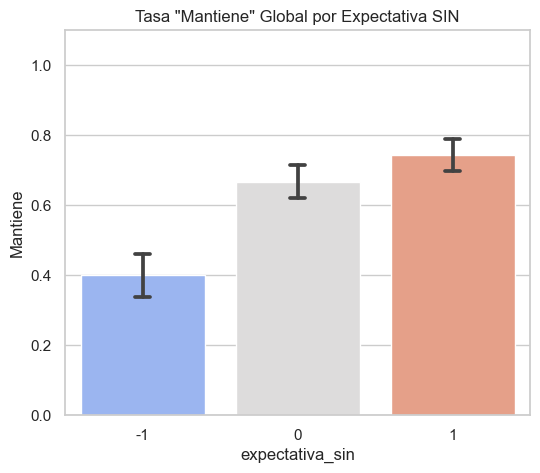

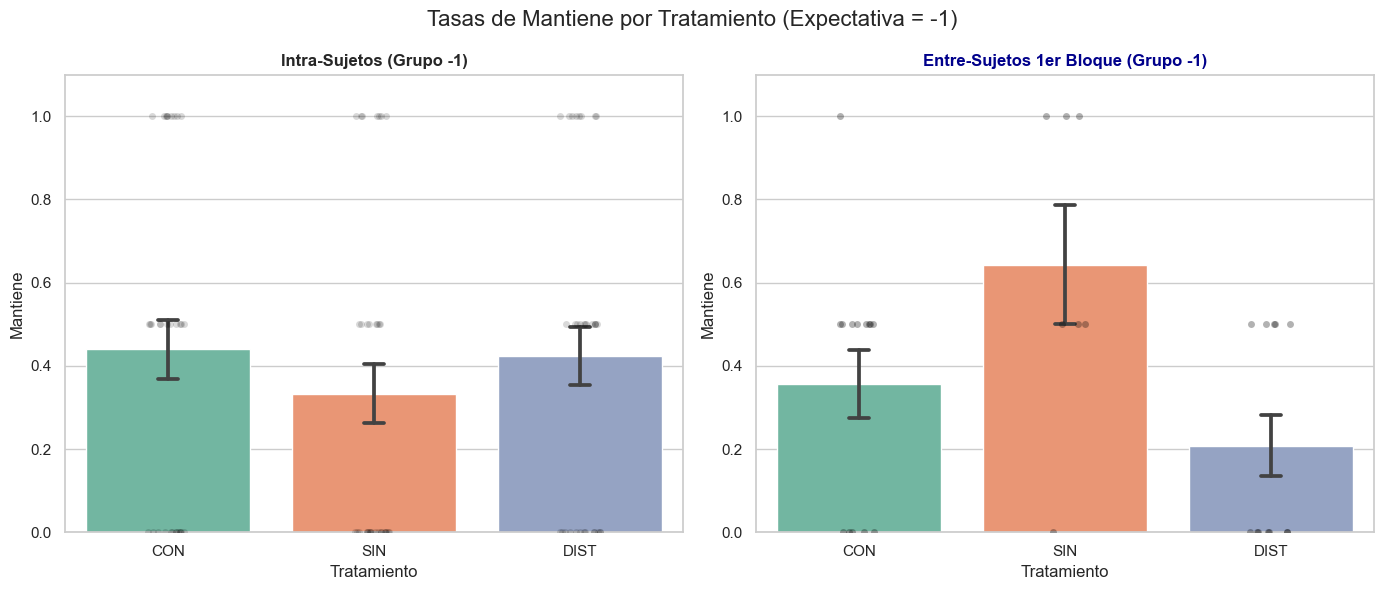


Tabla Intra-Sujetos (Grupo -1):
             count   mean    sem
Tratamiento                     
CON             33  0.439  0.071
SIN             33  0.333  0.071
DIST            33  0.424  0.069

Tabla Entre-Sujetos (Grupo -1):
             count   mean    sem
Tratamiento                     
CON             14  0.357  0.082
SIN              7  0.643  0.143
DIST            12  0.208  0.074
----------------------------------------

>>> GRUPO: 0


C:\Users\felip\AppData\Local\Temp\ipykernel_14020\861917576.py:63: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  df_panel1 = df_resumen_grupo.melt(


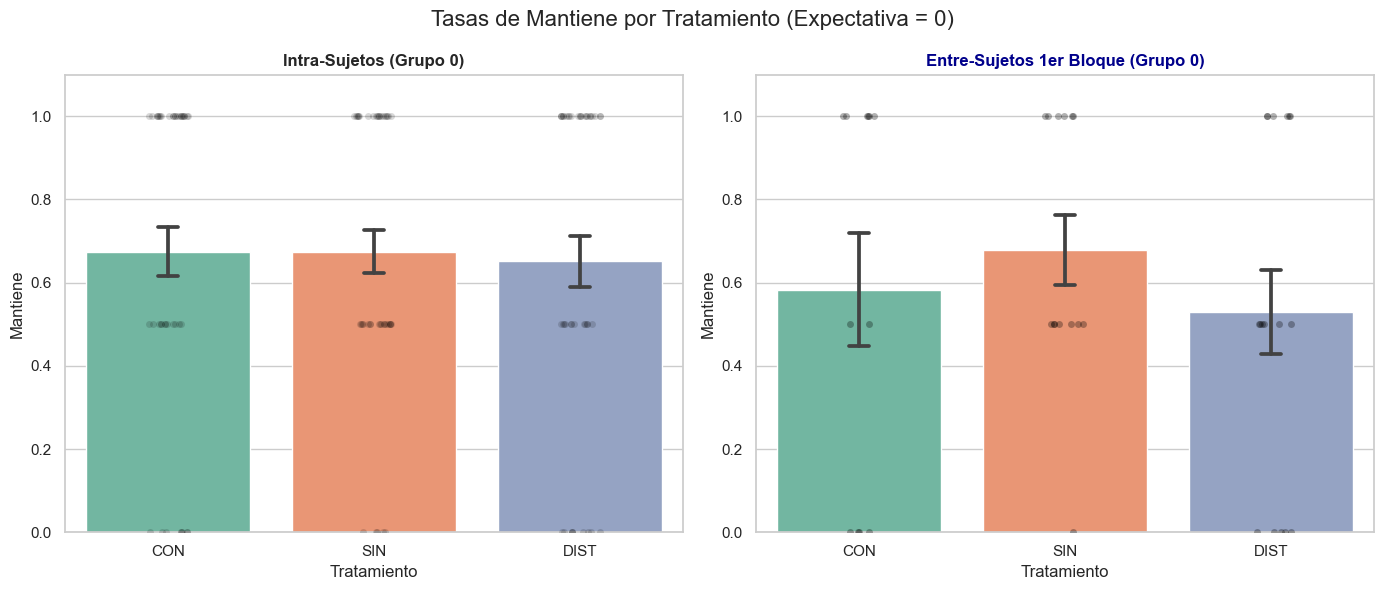


Tabla Intra-Sujetos (Grupo 0):
             count   mean    sem
Tratamiento                     
CON             43  0.674  0.060
SIN             43  0.674  0.052
DIST            43  0.651  0.061

Tabla Entre-Sujetos (Grupo 0):
             count   mean    sem
Tratamiento                     
CON             12  0.583  0.135
SIN             14  0.679  0.085
DIST            17  0.529  0.100
----------------------------------------

>>> GRUPO: 1


C:\Users\felip\AppData\Local\Temp\ipykernel_14020\861917576.py:63: FutureWarning: This dataframe has a column name that matches the 'value_name' column name of the resulting Dataframe. In the future this will raise an error, please set the 'value_name' parameter of DataFrame.melt to a unique name.
  df_panel1 = df_resumen_grupo.melt(


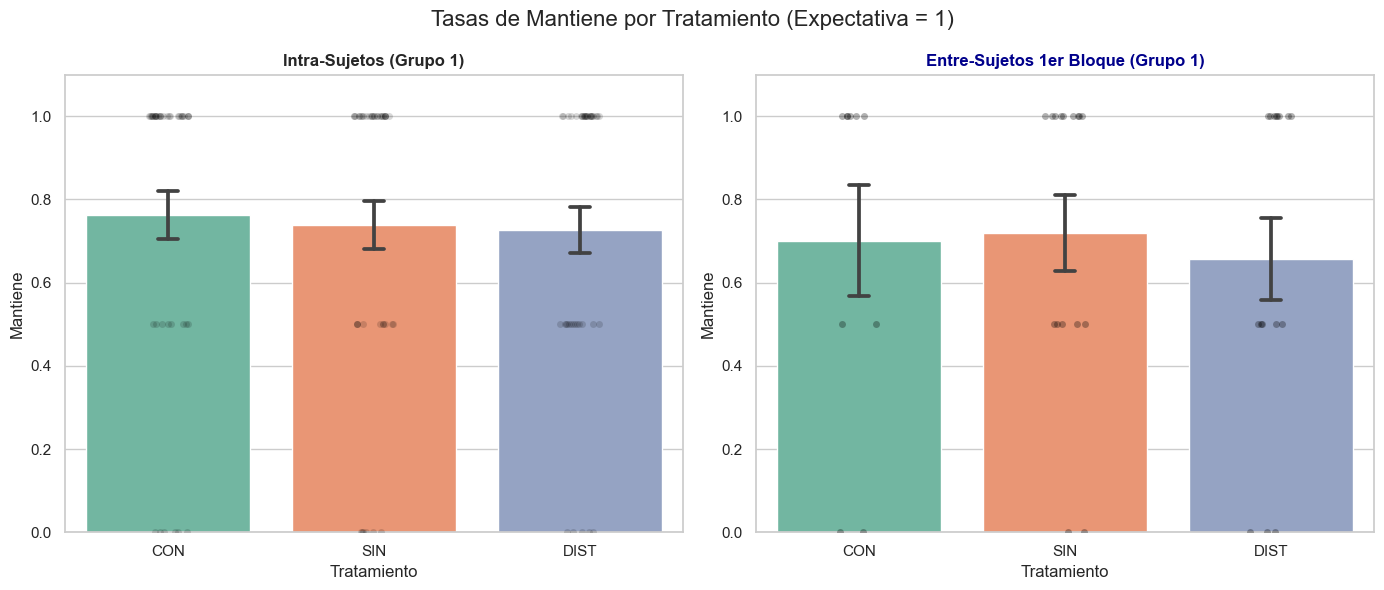


Tabla Intra-Sujetos (Grupo 1):
             count   mean    sem
Tratamiento                     
CON             42  0.762  0.057
SIN             42  0.738  0.057
DIST            42  0.726  0.054

Tabla Entre-Sujetos (Grupo 1):
             count   mean    sem
Tratamiento                     
CON             10  0.700  0.133
SIN             16  0.719  0.091
DIST            16  0.656  0.099
----------------------------------------


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CARGA Y PREPARACIÓN DE DATOS ---

# Definir variables
var_interes = 'expectativa_sin'
label_interes = 'Expectativa SIN'

print(f"\nAnalizando variable: {var_interes}")

# Crear Dataframes: Nivel Sujeto y Nivel Ensayo
# Para análisis intra-sujeto usamos una fila por sujeto
df_subj = df.drop_duplicates(subset=['ID_Sujeto']).copy()
if 'Mantiene' in df_subj.columns:
    df_subj = df_subj.drop(columns=['Mantiene']) # Eliminamos la columna de ensayo único

# Agregamos la media global del sujeto
global_mean = df.groupby('ID_Sujeto')['Mantiene'].mean().reset_index()
df_subj = df_subj.merge(global_mean, on='ID_Sujeto')

# --- 2. TASA MANTIENE GLOBAL ---
# Estadísticas por sujeto
subj_stats = df_subj.groupby(var_interes)['Mantiene'].agg(['count', 'mean', 'sem']).rename(columns={'count': 'N_Sujetos'})
# Estadísticas por ensayo (conteo total)
trial_stats = df.groupby(var_interes)['Mantiene'].count().rename('N_Ensayos')

summary_global = pd.concat([subj_stats, trial_stats], axis=1)

plt.figure(figsize=(6, 5))
sns.barplot(data=df_subj, x=var_interes, y='Mantiene', errorbar='se', capsize=0.1, palette='coolwarm')
plt.title(f'Tasa "Mantiene" Global por {label_interes}')
plt.ylim(0, 1.1)
plt.savefig('mantiene_global_P4RR_G4P_0.png')

print(f"\n--- Tasa Mantiene Global por {label_interes} ---")
print(summary_global.round(3))

# --- 3

# --- 5. DETALLE POR TRATAMIENTO Y GRUPO DE CREENCIA (Nuevo Requerimiento) ---
# Preprocesamiento para asegurar columna Tratamiento
df['Tratamiento'] = df['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)
col_grupo = var_interes

if col_grupo in df.columns:
    grupos = sorted(df[col_grupo].dropna().unique())
    print(f"\n{'='*60}")
    print(f" DESGLOSE POR TRATAMIENTO SEGÚN CREENCIA ({col_grupo})")
    print(f"{'='*60}")

    for grupo in grupos:
        print(f"\n>>> GRUPO: {grupo}")
        
        # Filtrar datos para este grupo específico
        ids_grupo = df[df[col_grupo] == grupo]['ID_Sujeto'].unique()
        df_resumen_grupo = df_subj[df_subj['ID_Sujeto'].isin(ids_grupo)].copy()
        df_long_grupo = df[df['ID_Sujeto'].isin(ids_grupo)].copy()

        # A. Panel Intra-Sujetos (Usando las columnas Promedio_ de df_subj)
        df_panel1 = df_resumen_grupo.melt(
            id_vars='ID_Sujeto', 
            value_vars=['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST'],
            var_name='Tratamiento', 
            value_name='Mantiene'
        )
        df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')

        # B. Panel Entre-Sujetos (Primer Bloque solamente)
        df_panel2 = df_long_grupo[df_long_grupo['Orden_1'] == 1].groupby(['ID_Sujeto', 'Tratamiento'])['Mantiene'].mean().reset_index()

        # --- VISUALIZACIÓN ---
        orden = ['CON', 'SIN', 'DIST']
        sns.set_theme(style="whitegrid")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Gráfico 1: Intra
        sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, 
                    palette='Set2', errorbar='se', capsize=.1, ax=axes[0])
        sns.stripplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, 
                      color='black', alpha=0.15, jitter=True, ax=axes[0])
        axes[0].set_title(f'Intra-Sujetos (Grupo {grupo})', fontsize=12, fontweight='bold')
        axes[0].set_ylim(0, 1.1)
        
        # Gráfico 2: Entre (Primer Bloque)
        sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, 
                    palette='Set2', errorbar='se', capsize=.1, ax=axes[1])
        sns.stripplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, 
                      color='black', alpha=0.3, jitter=True, ax=axes[1])
        axes[1].set_title(f'Entre-Sujetos 1er Bloque (Grupo {grupo})', fontsize=12, fontweight='bold', color='darkblue')
        axes[1].set_ylim(0, 1.1)
        
        plt.suptitle(f'Tasas de Mantiene por Tratamiento (Expectativa = {grupo})', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'panel_tratamientos_grupo_{grupo}.png')
        plt.show()

        # --- TABLAS ---
        print(f"\nTabla Intra-Sujetos (Grupo {grupo}):")
        print(df_panel1.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))
        
        print(f"\nTabla Entre-Sujetos (Grupo {grupo}):")
        print(df_panel2.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))
        print("-" * 40)